# Setup and imports

In [1]:
import os
import contextlib
import stan
import pandas as pd
import numpy as np
import scipy.stats as stats 
from datetime import datetime
import matplotlib.pyplot as plt
import pickle
import arviz as az
# this is a work around needed to run pystan in some machines
import nest_asyncio
nest_asyncio.apply()
from scipy.special import softmax
import pickle
import time
from concurrent.futures import ThreadPoolExecutor
from itertools import repeat

# Create a context manager to suppress all console output
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as fnull:
        with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
            yield
from pathlib import Path
from scipy.special import rel_entr



### Scratch

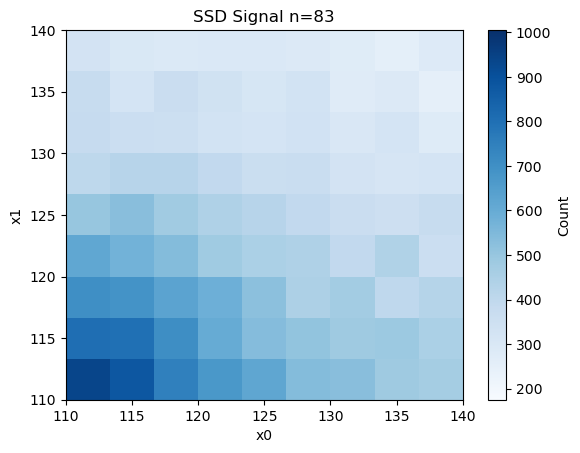

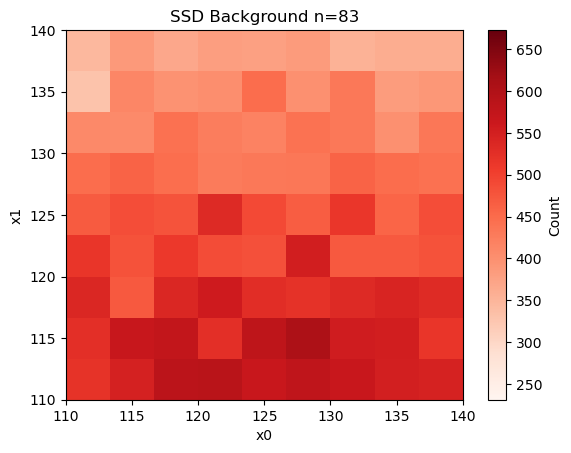

In [2]:
n=np.random.randint(1,499)
n=83
ssd_length=100000
path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
ts = ts[:ssd_length]
path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'    
tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
tb = tb[:ssd_length]

nbins=15 # although this is not the final number of bins between 110 and 140! (it is between 100 and 150)
# Plot 2D histogram for df_s
plt.hist2d(ts['x0'], ts['x1'], bins=nbins,cmap='Blues')
plt.xlim(110,140)
plt.ylim(110,140)
plt.colorbar(label='Count')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('SSD Signal n='+str(n))
plt.show()

# Plot 2D histogram for df_b
plt.hist2d(tb['x0'], tb['x1'], bins=nbins, cmap='Reds')
plt.xlim(110,140)
plt.ylim(110,140)
plt.colorbar(label='Count')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('SSD Background n='+str(n))
plt.show()

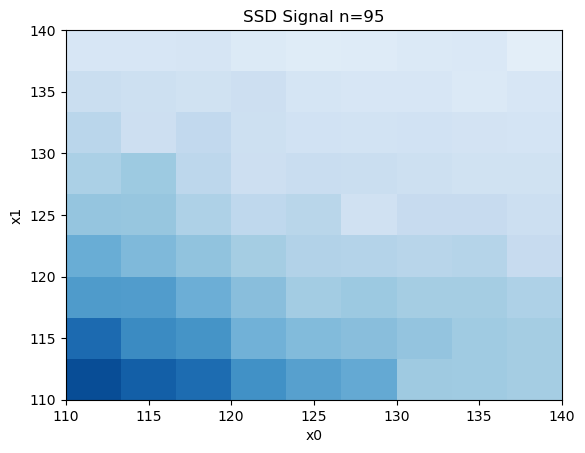

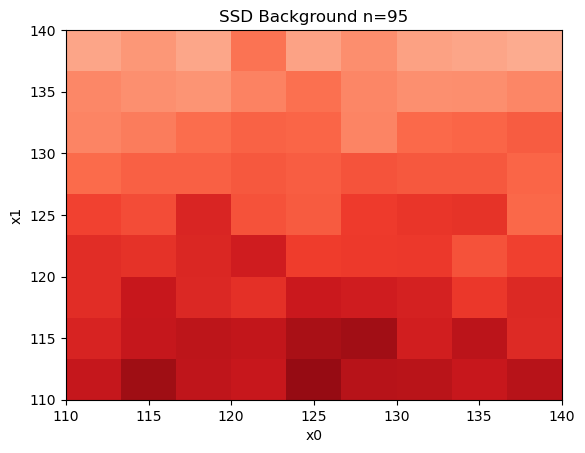

In [3]:
n=np.random.randint(1,499)
n=95
ssd_length=100000
path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
ts = ts[:ssd_length]
path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'   
tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
tb = tb[:ssd_length]

nbins=15
# Plot 2D histogram for df_s
counts = plt.hist2d(ts['x0'], ts['x1'], bins=nbins,cmap='Blues')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('SSD Signal n='+str(n))
plt.show()

# Plot 2D histogram for df_b
countb = plt.hist2d(tb['x0'], tb['x1'], bins=nbins, cmap='Reds')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('x0')
plt.ylabel('x1')
plt.title('SSD Background n='+str(n))
plt.show()

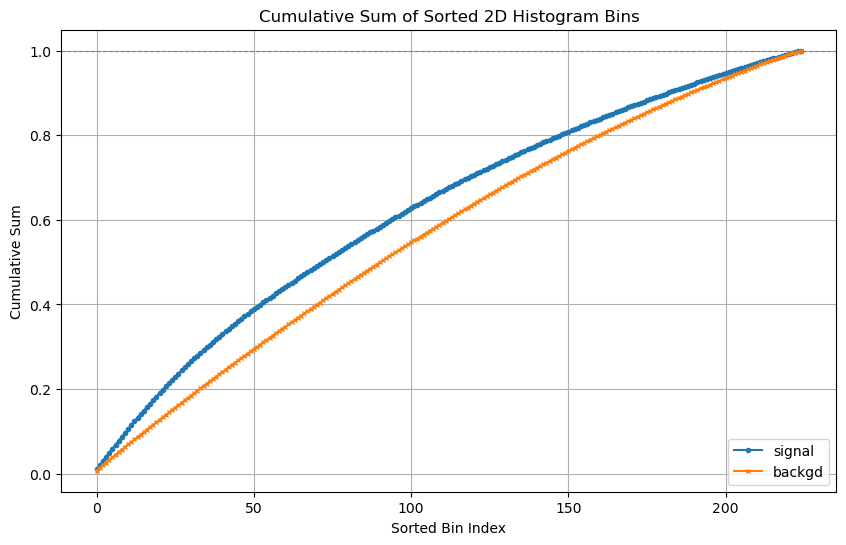

In [4]:
# Flatten the counts, normalize so they sum to 1
flattened_counts = counts[0].flatten()
normalized_counts = flattened_counts / flattened_counts.sum()
# Sort in descending order
sorted_counts = np.sort(normalized_counts)[::-1]
# Calculate cumulative sum
cumulative_sum_s = np.cumsum(sorted_counts)

flattened_counts = countb[0].flatten()
normalized_counts = flattened_counts / flattened_counts.sum()
# Sort in descending order
sorted_counts = np.sort(normalized_counts)[::-1]
# Calculate cumulative sum
cumulative_sum_b = np.cumsum(sorted_counts)

# Plot cumulative sum
plt.figure(figsize=(10, 6))
plt.plot(cumulative_sum_s, marker='o', markersize=3, label='signal')
plt.plot(cumulative_sum_b, marker='x', markersize=3, label='backgd')
plt.xlabel('Sorted Bin Index')
plt.ylabel('Cumulative Sum')
plt.title('Cumulative Sum of Sorted 2D Histogram Bins')
plt.legend()
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.show()

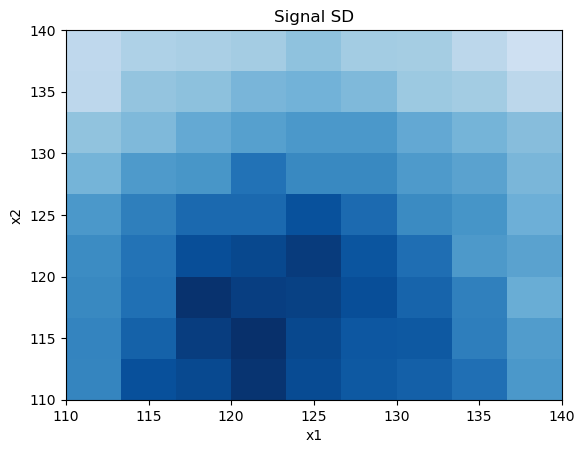

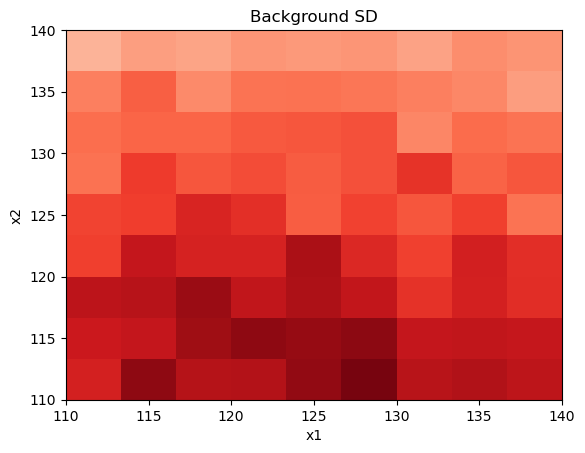

In [4]:
# SD
path_signal = Path('data') / 'dihiggs_sd_processed.dat'
#path_background = Path('data') / 'bbbb_sd_processed.dat'
path_background = Path('data') / 'bbbb_sd_combined_processed_feb_12.dat'


df_s = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
df_s = df_s[:ssd_length]
df_b = df_b[:ssd_length]

# Plot 2D histogram for df_s
plt.hist2d(df_s['x0'], df_s['x1'], bins=nbins, cmap='Blues')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Signal SD')
plt.show()

# Plot 2D histogram for df_b
plt.hist2d(df_b['x0'], df_b['x1'], bins=nbins, cmap='Reds')
plt.xlim(110,140)
plt.ylim(110,140)
#plt.colorbar(label='Count')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Background SD')
plt.show()

In [5]:
def compute_hellinger_distance(hist1, hist2):
    # Normalize the histograms
    p = hist1.ravel()
    q = hist2.ravel()
    
    # Normalize probabilities
    p /= np.sum(p)
    q /= np.sum(q)
    
    # Compute Hellinger distance
    hellinger_dist = np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2)) / np.sqrt(2)
    return hellinger_dist

In [6]:
def ssd_distances(n, ssd_length, nbins):
    # import synthetic data SD
    path_signal = Path('data') / 'dihiggs_sd_processed.dat'
    path_background = Path('data') / 'bbbb_sd_processed.dat'
    df_s = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_s = df_s[:ssd_length]
    df_b = df_b[:ssd_length]

    # import synthetic simulated data
    path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
    ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    ts = ts[:ssd_length]
    path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'  
    tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    tb = tb[:ssd_length]
    
    # Compute the 2D histograms
    signalSSD, _, _, _ = plt.hist2d(ts['x0'], ts['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSSD, _, _, _ = plt.hist2d(tb['x0'], tb['x1'], bins=nbins, density=True, cmap='Reds')
    signalSD, _, _, _ = plt.hist2d(df_s['x0'], df_s['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSD, _, _, _ = plt.hist2d(df_b['x0'], df_b['x1'], bins=nbins, density=True, cmap='Reds')
    plt.close()
    
    # Compute Hellinger distances between all pairs
    h_sssd_bssd = compute_hellinger_distance(signalSSD, backgroundSSD)
    h_sssd_ssd = compute_hellinger_distance(signalSSD, signalSD)
    h_sssd_bsd = compute_hellinger_distance(signalSSD, backgroundSD)
    h_bssd_ssd = compute_hellinger_distance(backgroundSSD, signalSD)
    h_bssd_bsd = compute_hellinger_distance(backgroundSSD, backgroundSD)
    h_ssd_bsd = compute_hellinger_distance(signalSD, backgroundSD)
    
    return h_sssd_ssd/h_sssd_bsd, h_bssd_bsd/h_bssd_ssd

In [9]:
out = []
goodns = []
badns = []
for n in range(1,499):
    x, y = ssd_distances(n, 100000, nbins)
    out.append([x,y])
    if x<0.9 and y<0.9:
        goodns.append(n)
    if x>1.1:
        badns.append(n)

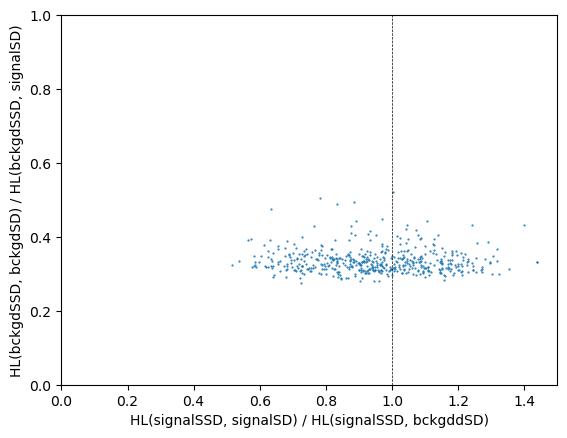

In [10]:
plt.scatter([x[0] for x in out],  [x[1] for x in out], s=0.3)
plt.xlim(0,1.5)
plt.ylim(0,1)
plt.axvline(x=1, color='black', linestyle='dashed', linewidth=0.5)
plt.xlabel('HL(signalSSD, signalSD) / HL(signalSSD, bckgddSD)')
plt.ylabel('HL(bckgdSSD, bckgdSD) / HL(bckgdSSD, signalSD)')
plt.show()

In [17]:
def sssd_distances(n, ssd_length, nbins): # signal ssd distances
    # import synthetic data SD
    path_signal = Path('data') / 'dihiggs_sd_processed.dat'
    path_background = Path('data') / 'bbbb_sd_processed.dat'
    df_s = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_s = df_s[:ssd_length]
    df_b = df_b[:ssd_length]

    # import synthetic simulated data
    path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
    ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    ts = ts[:ssd_length]
    path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'  
    tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    tb = tb[:ssd_length]
    
    # Compute the 2D histograms
    signalSSD, _, _, _ = plt.hist2d(ts['x0'], ts['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSSD, _, _, _ = plt.hist2d(tb['x0'], tb['x1'], bins=nbins, density=True, cmap='Reds')
    signalSD, _, _, _ = plt.hist2d(df_s['x0'], df_s['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSD, _, _, _ = plt.hist2d(df_b['x0'], df_b['x1'], bins=nbins, density=True, cmap='Reds')
    plt.close()
    
    # Compute Hellinger distances between all pairs
    #h_sssd_bssd = compute_hellinger_distance(signalSSD, backgroundSSD)
    h_sssd_ssd = compute_hellinger_distance(signalSSD, signalSD)
    h_sssd_bsd = compute_hellinger_distance(signalSSD, backgroundSD)
    #h_bssd_ssd = compute_hellinger_distance(backgroundSSD, signalSD)
    #h_bssd_bsd = compute_hellinger_distance(backgroundSSD, backgroundSD)
    #h_ssd_bsd = compute_hellinger_distance(signalSD, backgroundSD)
    
    return h_sssd_ssd/h_sssd_bsd

def bssd_distances(n, ssd_length, nbins): # background ssd distances
    # import synthetic data SD
    path_signal = Path('data') / 'dihiggs_sd_processed.dat'
    path_background = Path('data') / 'bbbb_sd_processed.dat'
    df_s = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    df_s = df_s[:ssd_length]
    df_b = df_b[:ssd_length]

    # import synthetic simulated data
    path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'    
    ts = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    ts = ts[:ssd_length]
    path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'  
    tb = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    tb = tb[:ssd_length]
    
    # Compute the 2D histograms
    signalSSD, _, _, _ = plt.hist2d(ts['x0'], ts['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSSD, _, _, _ = plt.hist2d(tb['x0'], tb['x1'], bins=nbins, density=True, cmap='Reds')
    signalSD, _, _, _ = plt.hist2d(df_s['x0'], df_s['x1'], bins=nbins, density=True, cmap='Blues')
    backgroundSD, _, _, _ = plt.hist2d(df_b['x0'], df_b['x1'], bins=nbins, density=True, cmap='Reds')
    plt.close()
    
    # Compute Hellinger distances between all pairs
    #h_sssd_bssd = compute_hellinger_distance(signalSSD, backgroundSSD)
    #h_sssd_ssd = compute_hellinger_distance(signalSSD, signalSD)
    #h_sssd_bsd = compute_hellinger_distance(signalSSD, backgroundSD)
    h_bssd_ssd = compute_hellinger_distance(backgroundSSD, signalSD)
    h_bssd_bsd = compute_hellinger_distance(backgroundSSD, backgroundSD)
    #h_ssd_bsd = compute_hellinger_distance(signalSD, backgroundSD)
    
    return h_bssd_bsd/h_bssd_ssd

In [22]:
out2 = []
goodns = []
badns = []
for n in range(len(out2),499):
    if n%10 == 0: print(n)
    xs = sssd_distances(n, 50000, mybinning)
    xb = bssd_distances(n, 50000, mybinning)
    out2.append([xs,xb])

210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490


In [ ]:
plt.hist([x[0] for x in out2])
plt.axvline(x=1, color='black', linestyle='dashed')
plt.title('Signal SSD Hellinger distance ratios')
plt.xlabel('H(signalSSD, signalSD)/H(signalSSD, backgroundSD)')
plt.show()
        

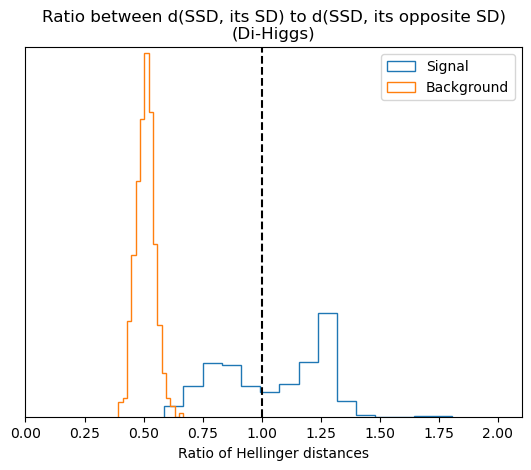

In [31]:
plt.hist([x[0] for x in out2], histtype='step', bins=15, density=1, label='Signal')
plt.hist([x[1] for x in out2], histtype='step', bins=15, density=1, label='Background')
plt.xlim(0,2.1)
plt.ylim(0,11)
plt.axvline(x=1, color='black', linestyle='dashed')
plt.title('Ratio between d(SSD, its SD) to d(SSD, its opposite SD)\n(Di-Higgs)')
plt.xlabel('Ratio of Hellinger distances')
plt.yticks([])
plt.legend()
plt.savefig('figs/ratio_distances.dihiggs.png')
plt.show()
        

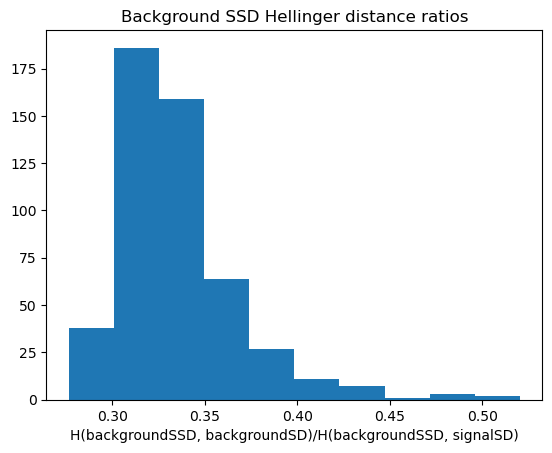

In [35]:
plt.hist([x[1] for x in out2])
plt.title('Background SSD Hellinger distance ratios')
plt.xlabel('H(backgroundSSD, backgroundSD)/H(backgroundSSD, signalSD)')
plt.show()

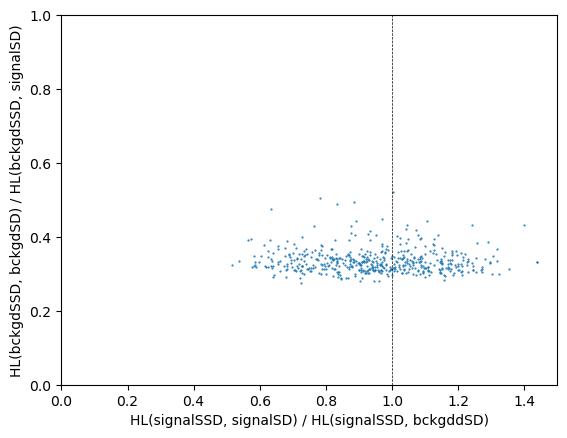

In [10]:
plt.scatter([x[0] for x in out],  [x[1] for x in out], s=0.3)
plt.xlim(0,1.5)
plt.ylim(0,1)
plt.axvline(x=1, color='black', linestyle='dashed', linewidth=0.5)
plt.xlabel('HL(signalSSD, signalSD) / HL(signalSSD, bckgddSD)')
plt.ylabel('HL(bckgdSSD, bckgdSD) / HL(bckgdSSD, signalSD)')
plt.show()

In [11]:
len(goodns), goodns[:10], badns[:10]

(192,
 [2, 3, 4, 5, 7, 11, 14, 17, 19, 22],
 [9, 15, 18, 25, 29, 32, 33, 40, 42, 45])

In [12]:
[x for x in out if x[0]<0.8]

[[0.6402012990984035, 0.32107929450527634],
 [0.7710840313273446, 0.3409572593912827],
 [0.6981686900550395, 0.3171719587299597],
 [0.6877390236507225, 0.3542414629074131],
 [0.6349826441872058, 0.4755649247177946],
 [0.7424938068774112, 0.3523710066204273],
 [0.5362046500543558, 0.3341016860612528],
 [0.7550765526941147, 0.3454472610084163],
 [0.7557785770229457, 0.306958964772984],
 [0.7291195993551095, 0.3035180562542719],
 [0.7121678102726957, 0.32250302153980015],
 [0.6347864777581992, 0.33945578198624793],
 [0.6378927925160862, 0.3163654369321076],
 [0.5752571645722692, 0.31802566493267026],
 [0.61192946866975, 0.37726925839988906],
 [0.7350995089896267, 0.348921739139729],
 [0.6410588659409809, 0.35617812147157013],
 [0.7016546122873385, 0.35727254294435523],
 [0.7683078070423153, 0.36342561985438226],
 [0.786105260207438, 0.29853488809967893],
 [0.6546346223154944, 0.3680502308851853],
 [0.6551675050170429, 0.32634159442338545],
 [0.694666881414466, 0.3370175436575964],
 [0.796

In [13]:
out[95]

[0.9721274062402218, 0.3466102672764615]

# Functions

We create 2 datasets, one SD = Synthetic Data, corresponds to what would be the true data in an experiment. The other, SSD = Synthetic Simulated Data, corresponds to what would be the simulated data in an experiment.  To emulate what really happens in an experiment, SSD $!=$ SD, but it has many patterns of it.

The original observable space is 2D, $x_0$ and $x_1$.  Following CMS Arena idea (and usual HEP practices), we convert a grid in this 2D space into a histogram in a 1D space.

In [14]:
def generate_sd_physical(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns, Nb, rseed=0, mybinning=[[],[]]):
    # We leave the arguments equal, even though most of them we don't use them.  Just to leave input and output qith the same structure.
    #np.random.seed(rseed)
    #sd_signal = pd.DataFrame(
    #    np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,Ns),
    #    columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    #sd_background = pd.DataFrame(
    #    np.random.multivariate_normal(mean_sd_background, covariance_sd_background,Nb),
    #    columns = ['x'+str(s) for s in range(len(mean_sd_background))])
    
    # Import the full Sd datasets for signal and background
    increase = 4 # factor to increase data such that he data in the fiducial region ends up being what was requested
    path_signal = Path('data') / 'dihiggs_sd_processed.dat'
    path_background = Path('data') / 'bbbb_sd_combined_processed_feb_12.dat'
    sd_signal = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
    sd_background = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
    # Select the required number of events
    sd_signal = sd_signal[:int(increase*Ns)]
    sd_background = sd_background[:int(increase*Nb)]
    mask_signal = (sd_signal['x0'] > 110) & (sd_signal['x0'] < 140) & (sd_signal['x1'] > 110) & (sd_signal['x1'] < 140)
    mask_background = (sd_background['x0'] > 110) & (sd_background['x0'] < 140) & (sd_background['x1'] > 110) & (sd_background['x1'] < 140)
    sd_signal = sd_signal.loc[mask_signal].head(Ns).reset_index(drop=True).copy()
    sd_background = sd_background.loc[mask_background].head(Nb).reset_index(drop=True).copy()

    if len(sd_background) < Nb: print('Atention, background length is: '+str(len(sd_background)) )
    if len(sd_signal) < Ns: print('Atention, signal length is: '+str(len(sd_signal)) )
        
    plt.scatter(sd_signal['x0'],sd_signal['x1'], s=0.5)
    plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5)
    for vline in mybinning[0]:
        plt.axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
    for hline in mybinning[1]:
        plt.axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
    plt.show()
    
    #### Data as a whole
    sd_data = pd.concat([sd_signal, sd_background])
    # Shuffle the merged DataFrame in place
    sd_data = sd_data.sample(frac=1).reset_index(drop=True)
    
    sd_data_hist  = flat_histogramdd(sd_data, mybinning)
    
    # For the sake of the inference problem, we better have the data as events, where each event is the bin number
    bins = [x-0.5 for x in range(len(sd_data_hist))]  # Bin edges
    frequencies = sd_data_hist  # Frequencies in each bin
    
    sd_data_hist1 = []
    for bin_edge, freq in zip(bins, frequencies):
        sd_data_hist1.extend([bin_edge+0.5] * int(freq))
        
    
    X0 = sd_data_hist
    # This is our data!!!! (we start with bin=1 because of STAN that starts counting on 1 and not on 0)
    X = [int(x+1) for x in sd_data_hist1]
    np.random.shuffle(X)
    return X, sd_signal, sd_background


In [15]:
def generate_ssd_physical_signal(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length):
    # We leave the arguments equal, even though most of them we don't use them.  Just to leave input and output qith the same structure.
    # SSD
    DF_ssd = []
    Y = []
    n = 1
    while (n<num_ssd+1): 
    #for n in goodns[:190]:
        path_signal = Path('data') / 'signal_ssds_big-var_processed' / f'dihiggs_ssd_big_var_{n}.dat'      
        t1 = pd.read_csv(path_signal, sep=r'\s+', header=None, names=['x0', 'x1'])
        t1 = t1[:ssd_length]
        #path_background = Path('data') / 'background_ssds_processed' / f'bbbb_ssd_{n}.dat'
        #df_b = pd.read_csv(path_background, sep=r'\s+', header=None, names=['col1', 'col2'])
        DF_ssd.append(t1)
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        Y.append(list(t2))
        n += 1
    
    return DF_ssd, np.array(Y)

def generate_ssd_physical_background(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length):
    # We leave the arguments equal, even though most of them we don't use them.  Just to leave input and output qith the same structure.
    # SSD
    DF_ssd = []
    Y = []
    n = 1
    while (n<num_ssd+1): 
    #for n in goodns[:190]:
        path_background = Path('data') / 'background_ssds_big-var_processed' / f'bbbb_ssd_big_var_{n}.dat'
        t1 = pd.read_csv(path_background, sep=r'\s+', header=None, names=['x0', 'x1'])
        t1 = t1[:ssd_length]
        DF_ssd.append(t1)
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        Y.append(list(t2))
        n += 1
    
    return DF_ssd, np.array(Y)

In [16]:
# this is legacy, it is serial
lda_serial = """
data {
  int<lower=1> N;              // number of SSDs (number of documents in LDA)
  int<lower=1> V;              // number of bins (vocabulary size in LDA)
  int<lower=1> K;              // number of topics
  int<lower=0> NN;              // total number of simulated events in all the SSDs (total number of words in LDA)
  array[NN] int<lower=1,upper=V> w;   // bin indices (1...V) (word indices in LDA)
  array[NN] int<lower=1,upper=N> doc; // SSD index (1...N), says to which SSD correspond bin nn-th (document indices in LDA)
  vector<lower=0>[K] alpha;    // Dirichlet prior for topics distributions in each SSD (topics distribution in each document in LDA)
  vector<lower=0>[V] eta;      // Dirichlet prior for bins distribution in each SSD (words distrubution per topic in LDA)
}

parameters {
  array[N] simplex[K] theta;         // topic proportions per SSD (per document in LDA).  This is the Z matrix, each row is a simplex
  array[K] simplex[V] W;            // bin distributions per topic (word distribution in LDA).  This is the topics matrix, and being a simplex, adds to 1 each row
}

model {
  // Priors
  for (n in 1:N)
    theta[n] ~ dirichlet(alpha);
  for (k in 1:K)
    W[k] ~ dirichlet(eta);

  // Likelihood
  for (nn in 1:NN) {
    vector[K] topic_lik;
    for (k in 1:K)
        topic_lik[k] = log(theta[doc[nn], k]) +  log(W[k, w[nn]]); 
    // Below is subtle:
    // in LDA: the prob of word w[nn] is the sum of the responsibilities for each topic, which is theta (prob of topic) times phi (prob of word inside that topic)      
    target += log_sum_exp(topic_lik);
  }
}"""

# this is legacy it is parallel but not optimized
lda_parallel_unoptimized="""
functions {
real partial_ll(array[] int w_slice, int start, int end,
array[] int doc,
array[] vector log_theta,   // precomputed log(theta): array[N] vector[K]
array[] vector log_W,       // precomputed log(W):     array[K] vector[V]
int K) {
real acc = 0;
int S = end - start + 1;
for (s in 1:S) {
int n = start + s - 1;
int d = doc[n];
int w_n = w_slice[s];
// accumulate log_sum_exp without allocating a vector each time
real lse = negative_infinity();
for (k in 1:K)
lse = log_sum_exp(lse, log_theta[d][k] + log_W[k][w_n]);
acc += lse;
}
return acc;
}
}
data {
int<lower=1> N;                             // number of SSDs (documents)
int<lower=1> V;                             // number of bins (vocab size)
int<lower=1> K;                             // number of topics
int<lower=0> NN;                            // total number of tokens
array[NN] int<lower=1,upper=V> w;           // word indices
array[NN] int<lower=1,upper=N> doc;         // document index per token
vector<lower=0>[K] alpha;                   // Dirichlet prior for theta rows
vector<lower=0>[V] eta;                     // Dirichlet prior for W rows
int<lower=1> grainsize;                     // e.g., 512–2048
}
parameters {
array[N] simplex[K] theta;                  // doc-topic proportions
array[K] simplex[V] W;                      // topic-word distributions
}
model {
// Priors
for (n in 1:N)
theta[n] ~ dirichlet(alpha);
for (k in 1:K)
W[k] ~ dirichlet(eta);

// Precompute logs once per evaluation
array[N] vector[K] log_theta;
array[K] vector[V] log_W;
for (n in 1:N) log_theta[n] = log(theta[n]);
for (k in 1:K) log_W[k] = log(W[k]);

// Parallelized likelihood
target += reduce_sum(partial_ll, w, grainsize, doc, log_theta, log_W, K);
}
"""

# we use this, it is parallel and optimized 
lda = """
functions {
// Parallel log-likelihood using aggregated counts per (document, bin),
// iterating only over nonzero bins for each document.
real partial_ll_counts(array[] int doc_slice, int start, int end,
array[] int pos,                 // length N+1, 1-based offsets
array[] int v_idx,               // length NNZ, bin indices
array[] int cnt,                 // length NNZ, counts
array[] vector log_theta,        // log(theta[d])
array[] vector log_W,            // log(W[k])
int K) {
real acc = 0;
int S = end - start + 1;

for (s in 1:S) {
  int d = doc_slice[s];            // document index
  int i1 = pos[d];
  int i2 = pos[d + 1] - 1;         // inclusive end
  if (i1 <= i2) {
    for (i in i1:i2) {
      int v = v_idx[i];
      int c = cnt[i];
      // log(sum_k theta[d,k] * W[k,v]) computed in log-space
      real lse = negative_infinity();
      for (k in 1:K)
        lse = log_sum_exp(lse, log_theta[d][k] + log_W[k][v]);
      if (c > 0) {acc += c * lse;}               // add all c observations at once
    }
  }
}
return acc;
}
}

data {
int<lower=1> N;                      // number of documents
int<lower=1> V;                      // number of bins (vocab size)
int<lower=1> K;                      // number of topics

// Sparse (ragged) representation of counts per document:
// Concatenate all nonzero (doc, bin) pairs across documents.
int<lower=0> NNZ;                    // total number of nonzero (doc, bin) entries
array[N + 1] int<lower=1, upper=NNZ + 1> pos;
// pos[d] is the 1-based starting index (into v_idx/cnt) for document d,
// and pos[d+1] is one past the end; require pos[1] == 1, pos[N+1] == NNZ + 1.

array[NNZ] int<lower=1, upper=V> v_idx; // bin index for each nonzero entry
array[NNZ] int<lower=0> cnt;            // count for each entry

vector<lower=0>[K] alpha;            // Dirichlet prior for theta rows
vector<lower=0>[V] eta;              // Dirichlet prior for W rows
int<lower=1> grainsize;              // e.g., 8–64 for per-doc slicing
}
transformed data {
// indices 1..N for reduce_sum slicing over documents
array[N] int doc_ids;
for (n in 1:N) doc_ids[n] = n;
}
parameters {
array[N] simplex[K] theta;           // doc-topic proportions
array[K] simplex[V] W;               // topic-word distributions
}
model {
// Priors
for (n in 1:N)
theta[n] ~ dirichlet(alpha);
for (k in 1:K)
W[k]   ~ dirichlet(eta);

// Precompute logs once per evaluation
array[N] vector[K] log_theta;
array[K] vector[V] log_W;
for (n in 1:N) log_theta[n] = log(theta[n]);
for (k in 1:K) log_W[k]     = log(W[k]);

// Parallelized likelihood over documents using counts (adds c * lse per bin)
target += reduce_sum(partial_ll_counts, doc_ids, grainsize, pos, v_idx, cnt, log_theta, log_W, K);
}"""

unmix = """
data {
int<lower=1> V;                           // number of bins
int<lower=1> K;                           // number of topics
int<lower=1> N;                           // number of observations
array[N] int<lower=1, upper=V> w;         // observed bin indices (1..V)

// Pre-fitted topic-word matrices for signal and background.
// Each row k is a simplex over V bins: W_c[k, v] = P(bin=v | topic=k, component=c)
array[K] simplex[V] W_signal;
array[K] simplex[V] W_background;

// Priors
vector<lower=0>[K] alpha_signal;          // Dirichlet prior for theta_s
vector<lower=0>[K] alpha_background;      // Dirichlet prior for theta_b
real<lower=0> a_pi;                       // Beta prior parameters for pi
real<lower=0> b_pi;
}

parameters {
simplex[K] theta_signal;                  // topic mixture for the signal component
simplex[K] theta_background;              // topic mixture for the background component
real<lower=0, upper=1> pi;                // fraction of signal in the data
}

transformed parameters {
// Implied per-bin distributions for each component (mixture over topics)
// phi_signal[v] = sum_k theta_signal[k] * W_signal[k, v]
// phi_background[v] = sum_k theta_background[k] * W_background[k, v]
vector<lower=0>[V] phi_signal;
vector<lower=0>[V] phi_background;

for (v in 1:V) {
real acc_s = 0;
real acc_b = 0;
for (k in 1:K) {
acc_s += theta_signal[k] * W_signal[k, v];
acc_b += theta_background[k] * W_background[k, v];
}
phi_signal[v] = acc_s;
phi_background[v] = acc_b;
}
}

model {
// Priors
theta_signal ~ dirichlet(alpha_signal);
theta_background ~ dirichlet(alpha_background);
pi ~ beta(a_pi, b_pi);

// Likelihood: for each observation w[n],
// P(w[n]) = pi * phi_signal[w[n]] + (1 - pi) * phi_background[w[n]]
// Use log_mix for numerical stability
for (n in 1:N) {
target += log_mix(pi, log(phi_signal[w[n]]), log(phi_background[w[n]]));
}
}

"""

# functions
def p_at_true(a,pi_true):
    """If 'a' is the histogram, then returns the valur of the histogram at the bin that contains p_true"""
    count = 0
    for i in a[1]:
        if i > pi_true: break
        count += 1
    #return a[0][count-1]/(a[1][1]-a[1][0])
    return a[0][count-1]


def smear_covariance_matrix(A, smearing=0.2, exception=[]):
    """Smear a covariance matrix normally around its values with std=smearing.
    If exception!=0, then the element exception[0],exception[1] is not smeared, but instead is fixed to exception[2] x its original value + exception[3]."""
    A = np.array(A)
    n = len(A)
    M = np.zeros((n, n), dtype=float) 
    while (np.linalg.det(M)<0 or sum(sum(M==0))==4): #keep on smearing until M is semi-definite positive to be a covariance
        for i in range(n):
            for j in range(i,n):
                if len(exception)>0 and i==exception[0] and j==exception[1]:
                    M[i,j] = A[i,j]*exception[2] + exception[3]
                    M[j,i] = M[i,j]
                else:
                    if i==j:
                        M[i,i] = abs(np.random.normal(A[i,i],max(smearing, A[i,i]*smearing)))
                    else:
                        M[i,j] = np.round(np.random.normal(A[i,j],max(smearing, A[i,j]*smearing)),2)
                        M[j,i] = M[i,j]
    return M

def smear_mean(mu, smearing=0.2, exception=[]):
    mu = np.array(mu)
    n = len(mu)
    Mu = np.empty(n, dtype=float)
    for i in range(n):
        if len(exception)>0 and i==exception[0]:
            Mu[i] = mu[i]*exception[1] + exception[2]
        else:            
            Mu[i] = np.round(np.random.normal(mu[i],max(smearing, mu[i]*smearing)),2) 
    return Mu
        

def generate_sd(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns, Nb, rseed=0, mybinning=[[],[]]):
    np.random.seed(rseed)
    sd_signal = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_signal, covariance_sd_signal,Ns),
        columns = ['x'+str(s) for s in range(len(mean_sd_signal))])
    sd_background = pd.DataFrame(
        np.random.multivariate_normal(mean_sd_background, covariance_sd_background,Nb),
        columns = ['x'+str(s) for s in range(len(mean_sd_background))])

    plt.scatter(sd_signal['x0'],sd_signal['x1'], s=0.5)
    plt.scatter(sd_background['x0'],sd_background['x1'], s=0.5)
    for vline in mybinning[0]:
        plt.axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
    for hline in mybinning[1]:
        plt.axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
    plt.show()
    
    #### Data as a whole
    sd_data = pd.concat([sd_signal, sd_background])
    # Shuffle the merged DataFrame in place
    sd_data = sd_data.sample(frac=1).reset_index(drop=True)
    
    sd_data_hist  = flat_histogramdd(sd_data, mybinning)
    
    # For the sake of the inference problem, we better have the data as events, where each event is the bin number
    bins = [x-0.5 for x in range(len(sd_data_hist))]  # Bin edges
    frequencies = sd_data_hist  # Frequencies in each bin
    
    sd_data_hist1 = []
    for bin_edge, freq in zip(bins, frequencies):
        sd_data_hist1.extend([bin_edge+0.5] * int(freq))
        
    
    X0 = sd_data_hist
    # This is our data!!!! (we start with bin=1 because of STAN that starts counting on 1 and not on 0)
    X = [int(x+1) for x in sd_data_hist1]
    np.random.shuffle(X)
    return X, sd_signal, sd_background


def flat_histogramdd(df, bins):
    """Receives a dataframe of D dimensions and N datapoints; and a list of how to bin in each one of the D dimensions.
    Returns a flatten historgram with the counting of datapoints in each bin in the D-dimensional grid."""
    cols = df.columns[:len(bins)]
    edges = [np.asarray(b) for b in bins]
    data = df[cols].dropna().to_numpy()
    return np.histogramdd(data, bins=edges)[0].ravel()

def normalize(a, epsilon=0.001):
    a = a + epsilon
    a = list(a)
    a = [x/sum(a) for x in a]
    #b = np.round(a / np.sum(a),4)
    #print(np.sum(b))
    return a

def normalize_prob(x,epsilon=0.0001):
    x = x + epsilon
    x = np.asarray(x, dtype=np.float64)
    s = x.sum(dtype=np.float64)
    y = x / s
    i = y.argmax()                     # adjust the largest to keep all positive
    y[i] += 1.0 - y.sum(dtype=np.float64)
    return y

def generate_ssd_Sean(mean_sd, covariance_sd, mybinning, exclusion, var, bias, num_ssd, ssd_length):
    count = 0
    means = []
    covs = []
    DF_ssd = []
    Y = []
    [true_mean_x0, true_mean_x1] = [mean_sd[0], mean_sd[1]] # removed the '+ bias' from here
    [[true_sigma, true_covariance], [_, _]] = covariance_sd
    while (count < num_ssd):
        biased_mean_x0 = np.random.normal(true_mean_x0, var)
        biased_mean_x1 = np.random.normal(true_mean_x1+bias, var) # and put it here
        biased_sigma = abs(np.random.normal(true_sigma, var))
        biased_covariance = np.random.normal(true_covariance, var)
        if (((biased_mean_x0 - true_mean_x0)**2 + (biased_mean_x1 - true_mean_x1)**2 > exclusion**2) and # so that here we correctly exclude what we want
            abs(biased_sigma - true_sigma) > exclusion and
            abs(biased_covariance - true_covariance) > exclusion/2 and
            (biased_sigma > 0) and
            (biased_sigma**2 - biased_covariance**2 > 0)):
            count += 1
            mean_ssd = [biased_mean_x0, biased_mean_x1]
            covariance_ssd = [[biased_sigma, biased_covariance],
                                         [biased_covariance, biased_sigma]]
            means.append(mean_ssd)
            covs.append(covariance_ssd)
            t1 = pd.DataFrame(np.random.multivariate_normal(mean_ssd, covariance_ssd, ssd_length), 
                columns=['x'+str(s) for s in range(len(mean_sd))])
            DF_ssd.append(t1)
            t2 = normalize_prob(flat_histogramdd(t1,mybinning))
            Y.append(list(t2))
        
    return DF_ssd, np.array(Y)

def generate_ssd(exception_signal, exception_background, mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Nssd_signal, Nssd_background, Nssd_signal_events, Nssd_background_events, rseed=0,  plot=[]):
    np.random.seed(rseed)
    # define which parameter is shifted and not smeared
    #exception_signal = [[],[0,1,1.2,0.1]]   # alway bias the (0,1) element of the covariance matrix, others smeare them around their true value
    #exception_background = [[0,1.2,0.1],[]] # always bias the oth element of the mean, others smear them around their true values
    # Nssd_signal = 500
    # Nssd_background = 500
    Yss=[]
    Ybb=[]
    
    ssd_signal = []
    DF_ssd_signal = []
    for i in range(Nssd_signal):
        t1 = pd.DataFrame(np.random.multivariate_normal(smear_mean(mean_sd_signal, exception=exception_signal[0]), smear_covariance_matrix(covariance_sd_signal, exception=exception_signal[1]),int(Ns)*10), columns=['x'+str(s) for s in range(len(mean_sd_signal))])
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        ssd_signal.append(list(t2))
        DF_ssd_signal.append(t1)
    
    ssd_background = []
    DF_ssd_background = []
    for i in range(Nssd_background):
        t1 = pd.DataFrame(np.random.multivariate_normal(smear_mean(mean_sd_background, exception=exception_background[0]), smear_covariance_matrix(covariance_sd_background,exception=exception_background[1]),Nb*10), columns=['x'+str(s) for s in range(len(mean_sd_background))])
        t2 = normalize_prob(flat_histogramdd(t1,mybinning))
        ssd_background.append(list(t2))
        DF_ssd_background.append(t1)
        
    Ys = np.array(ssd_signal)
    Yb = np.array(ssd_background)

    if len(plot)>0:
        p_signal = plot[0]
        p_background = plot[1]
        HL_S_prior = []
        HL_B_prior = []
        # Prior
        for i in range(4):
            # First Signal
            # Get the binned signal posterior of the i-th prior sample
            tmp_S = Ys[i]
            tmp_B = Yb[i]
            # Compute the HL distance between the i-th sample and the true
            HL_S = 0    
            HL_B = 0
            for n in range(len(p_signal)):
                HL_S += (np.sqrt(p_signal[n]) - np.sqrt(tmp_S[n]))**2
                HL_B += (np.sqrt(p_background[n]) - np.sqrt(tmp_B[n]))**2
            HL_S_prior.append(np.sqrt(HL_S))    
            HL_B_prior.append(np.sqrt(HL_B))           
        fig, axes = plt.subplots(2, 4, figsize=(12, 6), constrained_layout=True)        
        ## first row
        axes[0, 0].scatter(sd_signal['x0'],sd_signal['x1'], s=0.5)
        axes[0, 0].set_title('SD Signal')
        for vline in mybinning[0]:
            axes[0, 0].axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
        for hline in mybinning[1]:
            axes[0, 0].axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black') 
        for col in range(1,4):
            axes[0, col].scatter(Yss[col]['x0'], Yss[col]['x1'], s=0.5)
            axes[0, col].set_title('SSD Signal #'+str(col)+', HL='+str(np.round(HL_S_prior[col],2)))
            for vline in mybinning[0]:
                axes[0, col].axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
            for hline in mybinning[1]:
                axes[0, col].axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
        ## second row
        axes[1, 0].scatter(sd_background['x0'],sd_background['x1'], s=0.5, color='orange')
        axes[1, 0].set_title('SD Background')
        for vline in mybinning[0]:
            axes[1, 0].axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
        for hline in mybinning[1]:
            axes[1, 0].axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black') 
        
        for col in range(1,4):
            axes[1, col].scatter(Ybb[col]['x0'], Ybb[col]['x1'], s=0.2, color='orange')
            axes[1, col].set_title('SSD Background #'+str(col)+', HL='+str(np.round(HL_B_prior[col],2)))
            for vline in mybinning[0]:
                axes[1, col].axvline(x=vline, linewidth=0.5, linestyle='dashed', color='black')
            for hline in mybinning[1]:
                axes[1, col].axhline(y=hline, linewidth=0.5, linestyle='dashed', color='black')
        plt.show()
    return DF_ssd_signal, DF_ssd_background, Ys, Yb

def convert(list_of_dataframes, mybinning):
    #convert all SSD signal events into 3 lists to feed the LDA model
    cnt = []
    v_idx = []
    pos = [1]
    for i in range(len(list_of_dataframes)):
        counts = flat_histogramdd(list_of_dataframes[i], mybinning)
        int_counts = counts.astype(int)
        for i in range(len(int_counts)):
            v_idx.append(i+1)
            cnt.append(int_counts[i])
        pos.append(pos[-1]+len(int_counts))
    return cnt, v_idx, pos

def lda_function(thedata, nsamples, nwarmup, mydelta, rseed=0):
    model = stan.build(lda, data=thedata, random_seed=rseed)
    fit = model.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta)  # threads per chain)
    samples = fit.to_frame() 
    samples.sort_values(by='lp__', inplace=True, ascending=False)
    #
    # Let's diagnose the inference, we plot Rhat to assess chains convergence
    azdata = az.from_pystan(fit)
    summary = az.summary(azdata)
    tmp = summary['r_hat']
    print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
    plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
    plt.show()
    #
    return samples, summary

def unmix_data(data_unmix, num_samples, num_warmup, delta, random_seed=0, plot_it=1):
    model_unmix = stan.build(unmix, data=data_unmix, random_seed=random_seed)
    fit_unmix = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, refresh=0);
    samples_unmix = fit_unmix.to_frame() 
    samples_unmix.sort_values(by='lp__', inplace=True, ascending=False)
    #
    if plot_it==1:
        # Let's diagnose the inference, we plot Rhat to assess chains convergence
        azdata = az.from_pystan(fit_unmix)
        summary = az.summary(azdata)
        tmp = summary['r_hat']
        print('Rhat (max, mean, std):', np.max(tmp), np.mean(tmp), np.std(tmp))
        plt.hist(tmp, density=1, bins=np.linspace(1,3,30))
        plt.show()
        return samples_unmix, summary
    else:
        return samples_unmix

def unmix_bayesian(X, samples_s, samples_b,  V, K2, num_samples, num_warmup, delta, M=5, rseed=0):
    Ws_background = []
    #for m in range(M):
    for _ in range(M):
        m = np.random.randint(len(samples_b))
        W_background = []
        for k in range(1,K+1):
            topic = []
            for v in range(1,V+1):
                topic.append(samples_b.iloc[m]['W.'+str(k)+'.'+str(v)])
            W_background.append(topic)            
        Ws_background.append(W_background)
    
    Ws_signal = []
    #for m in range(M): # use this line for the most likely, use 2 lines below for random
    for _ in range(M):
        m = np.random.randint(len(samples_s))
        W_signal = []
        for k in range(1,K+1):
            topic = []
            for v in range(1,V+1):
                topic.append(samples_s.iloc[0]['W.'+str(k)+'.'+str(v)])
            W_signal.append(topic) 
        Ws_signal.append(W_signal)
    
    ################
    pis_bayesian = []
    for m in range(M):
        data_unmix =  { 
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'N': len(X),
                    'w': np.array(X),
                    'W_signal': np.array(Ws_signal[m]),
                    'W_background': np.array(Ws_background[m]),
                    'alpha_signal': np.array([1]*K2),
                    'alpha_background': np.array([1]*K2),
                    'a_pi': 1,
                    'b_pi': 1}                
        samples_unmix, summary = unmix_data(data_unmix, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, random_seed=0);
        #model_unmix = stan.build(unmix, data=data_unmix, random_seed=rseed);
        #fit_unmix, summary = model_unmix.sample(num_chains=4, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta);  # threads per chain)
        #samples_unmix = fit_unmix.to_frame() 
        pis_bayesian.extend(list(samples_unmix['pi'].values))
    return pis_bayesian
    
def unmix_data_for_parallel(one_argument):
    samples_unmix = unmix_data(one_argument[0], num_samples=one_argument[1], num_warmup=one_argument[2], delta=one_argument[3], random_seed=np.random.randint(10000), plot_it=0);
    return list(samples_unmix['pi'].values)

def run_unmix_M_times_concat(X, n_runs, workers):
    with ThreadPoolExecutor(max_workers=workers) as ex:
        # runs unmix_bayesian(X) 20 times in parallel (up to 10 at a time)
        results = list(ex.map(unmix_data_for_parallel, repeat(X, n_runs)))
    # flatten list-of-lists
    combined = [item for sub in results for item in sub]
    return combined



def assessment(p_signal, p_background, Ys, Yb, samples_unmix, runname=''):
    D = len(p_signal)
    samples_unmix.sort_values(by='lp__', ascending=False, inplace=True) # Therefore the first of the list corresponds to the MAP
    HL_S_posterior = []
    HL_B_posterior = []
    HL_S_prior = []
    HL_B_prior = []
    for i in range(len(samples_unmix)):
        # Get the binned signal posterior of the i-th sample
        tmp_S = []
        tmp_B = []
        for d in range(D):
            tmp_S.append(samples_unmix.iloc[i]['phi_signal.'+str(d+1)]) 
            tmp_B.append(samples_unmix.iloc[i]['phi_background.'+str(d+1)]) 
        # Compute the KL distance between the i-th sample and the true
        HL_S = 0
        HL_B = 0
        for n in range(len(p_signal)):
            HL_S += (np.sqrt(p_signal[n]) - np.sqrt(tmp_S[n]))**2
            HL_B += (np.sqrt(p_background[n]) - np.sqrt(tmp_B[n]))**2
        HL_S_posterior.append(np.sqrt(HL_S))
        HL_B_posterior.append(np.sqrt(HL_B))
    # Prior
    for i in range(len(Ys)):
        # First Signal
        # Get the binned signal posterior of the i-th prior sample
        tmp_S = Ys[i]
        tmp_B = Yb[i]
        # Compute the KL distance between the i-th sample and the true
        HL_S = 0    
        HL_B = 0
        for n in range(len(p_signal)):
            HL_S += (np.sqrt(p_signal[n]) - np.sqrt(tmp_S[n]))**2
            HL_B += (np.sqrt(p_background[n]) - np.sqrt(tmp_B[n]))**2
        HL_S_prior.append(np.sqrt(HL_S))    
        HL_B_prior.append(np.sqrt(HL_B))    
    #Plots
    mybins = np.linspace(0,max(max(HL_S_prior, HL_B_prior, HL_S_posterior, HL_B_posterior)),100)
    plt.hist(HL_S_prior, histtype='step', density=1, bins=mybins, color='red', label='SSDs signal prior')
    plt.hist(HL_S_posterior, histtype='step', density=1, bins=mybins, color='blue', label='Topics Model Posterior')
    plt.axvline(x=HL_S_posterior[0], linestyle='dashed', color='blue', label='Topics Model MAP')
    plt.title('Signal HL distance in the 1D binned histogram\n'+runname)
    plt.xlim(0,)
    plt.yticks([])
    plt.xlabel('HL distance (True, $i^{th}$ sample)')
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.signal-distributions.png')
    plt.show()
    
    ##
    plt.hist(HL_B_prior, histtype='step', density=1, bins=mybins, color='red', label='SSDs background prior')
    plt.hist(HL_B_posterior, histtype='step', density=1, bins=mybins, color='blue', label='Topics Model Posterior')
    plt.axvline(x=HL_B_posterior[0], linestyle='dashed', color='blue', label='Topics Model MAP')
    plt.title('Background HL distance in the 1D binned histogram\n'+runname)
    plt.xlim(0,)
    plt.yticks([])
    plt.xlabel('HL distance (True, $i^{th}$ sample)')
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.background-distributions.png')
    plt.show()
    
    # partial plot and saving of current results
    print('Unmixing Bayesianly...')
    pis_bayesian = run_unmix_M_times_concat([data_unmix, nsamples, nwarmup, mydelta, rseed], M, workers)
  
    plt.hist(samples_unmix['pi'], histtype='step', density=1, bins=20, label='MAP')
    plt.hist(pis_bayesian, histtype='step', density=1, bins=20, label='Posterior over topics')
    plt.axvline(x=pi_true, color='black', linestyle='dashed')
    plt.title('Posterior for signal fraction\n'+runname)
    plt.axhline(y=1, linestyle='dashed', color='black') 
    plt.xlim(0,1)
    plt.legend()
    if runname != '':
        plt.savefig('results/'+runname+'.signal-fraction.png')    
    plt.show()
    return


def create_var_dict(**kwargs):
    return kwargs

def load_and_assign(mykey):
    with open('results/'+mykey+'_mydict.pkl', 'rb') as f:
        data = pickle.load(f)   
    # Assign dictionary items to local variables
    for key, value in data.items():
        globals()[key] = value
    print(list(data.keys()))
    return 

# Main

### You can define your run, or alternatively import from previous run and modify only what you need

runname: 20260131_015844parallel-optimized


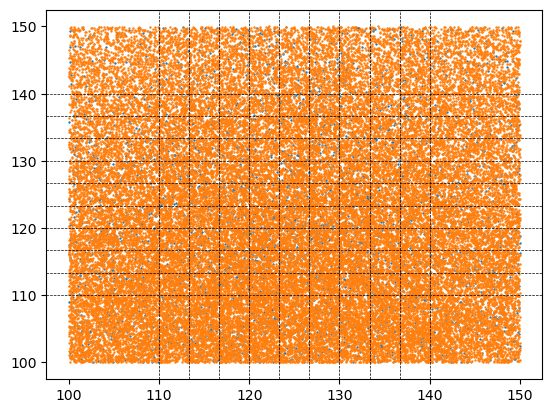

2286 19386 0.1055
Extracting signal...
Building...



Building: found in cache, done.Messages from stanc:
Warning in '/tmp/httpstan_6mxlv9yv/model_v3ncaotp.stan', line 77, column 10: The
    variable partial_ll_counts may not have been assigned a value before its
    use.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
    provided, or the prior(s) depend on data variables. In the later case,
    this may be a false positive.
Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   0% (2/8000)
Sampling:   0% (3/8000)
Sampling:   0% (4/8000)
Sampling:   1% (103/8000)
Sampling:   3% (202/8000)
Sampling:   4% (301/8000)
Sampling:   5% (400/8000)

AttributeError: 'NoneType' object has no attribute 'to_frame'

In [17]:
# I prefer to don't create a main() functions, so that all variables values stay in the scope to eventually further explore them
runname = datetime.now().strftime("%Y%m%d_%H%M%S") + 'parallel-optimized'
print('runname: '+runname)
############
mybinning = [np.linspace(110,140,10),np.linspace(110,140,10)] #fiduciary region only
mean_sd_signal = [0, 0]
covariance_sd_signal = [[1, 0], [0, 1]]
mean_sd_background = [0, 1]
covariance_sd_background = [[3, 0.4], [0.4, 3]]
Ns0 = 5000
Nb0 = 50000
# Define which parameter is shifted and not just smeared arouund its true.
# The first element is a list with three elements: 1st: which element of the mean is shifted; 2nd: factor of shifting wrt to the true; 3rd: absolut shift wrt to the true
# The second element is the same, but in the covariance, hence the first two elements are the position of the parameter to be shifted.
# Enpty element means no shift.
exception_signal = [[1,0,-0.2],[]]   
exception_background = [[],[0,1,1.5,0]] 


Nssd_signal = 500
Nssd_background = 500
# STAN parameters
K2 = 15 # number of topics
M = 20 # how many W's posterior samples in the full bayesian signal fraction extraction
workers = 20
rseed = 0
nsamples = 1000 # number of samples in all the STAN inference running
nwarmup = 1000 # idem for warmup
mydelta = 0.9# 0.95
mynote="""
Add any note about the run here

seed=0

"""
############################
############################
############################
############################
############################
############################

execution_times = ['Execution times:\n\n']
X, sd_signal, sd_background = generate_sd_physical(mean_sd_signal, covariance_sd_signal, mean_sd_background, covariance_sd_background, Ns0, Nb0, mybinning=mybinning, rseed=rseed)
t_s  = flat_histogramdd(sd_signal, mybinning)
t_b = flat_histogramdd(sd_background, mybinning)
Ns = int(sum(t_s))
Nb = int(sum(t_b))
pi_true = np.round(Ns/(Ns + Nb),4)
p_signal = normalize_prob(t_s)
p_background = normalize_prob(t_b)
print(Ns, Nb, pi_true)


### Sean adaptation ###
# instead of generating SSD as usual we use Sean's adaptation to have the same SSDs
exclusion = 0.3
var = 0.3
bias_signal = 0.3
bias_bkg = -0.3
#num_ssd = 500
ssd_length = max(Ns0,Nb0)*5

DF_ssd_signal, Ys = generate_ssd_physical_signal(
    mean_sd_signal, covariance_sd_signal, mybinning,
    exclusion, var, bias_signal, Nssd_signal, ssd_length)

DF_ssd_background, Yb = generate_ssd_physical_background(
    mean_sd_background, covariance_sd_background, mybinning,
    exclusion, var, bias_signal, Nssd_background, ssd_length)

### End Sean adapatation ###

start_time = time.time()

############################
############################
############################
############################
############################
############################

cnt_s, v_idx_s, pos_s = convert(DF_ssd_signal, mybinning)
cnt_b, v_idx_b, pos_b = convert(DF_ssd_background, mybinning)

data_lda_signal =  {'N': Nssd_signal,
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'NNZ': len(v_idx_s), 
                    'pos': pos_s,
                    'v_idx': v_idx_s,
                    'cnt': cnt_s,                    
                    'alpha': np.array([1]*K2),
                    'eta': np.array([1] * (len(mybinning[0])-1) * (len(mybinning[1])-1)),
                    "grainsize": 8}  # maybe use number of bins in the grid, e.g. 11 x 11 = 122

data_lda_background =  {'N': Nssd_signal,
                    'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                    'K': K2,
                    'NNZ': len(v_idx_s), 
                    'pos': pos_b,
                    'v_idx': v_idx_b,
                    'cnt': cnt_b,                    
                    'alpha': np.array([1]*K2),
                    'eta': np.array([1] * (len(mybinning[0])-1) * (len(mybinning[1])-1)),
                    "grainsize": 8}

print('Extracting signal...')
samples_s, summary_s = lda_function(data_lda_signal, nsamples, nwarmup, mydelta, rseed=rseed)
end_time1 = time.time()
elapsed_time = (end_time1 - start_time) / 60
execution_times.extend(['signal topic extraction:', elapsed_time])

############# start partial write down ####################
mydict = create_var_dict(mybinning=mybinning, mean_sd_signal=mean_sd_signal, mean_sd_background=mean_sd_background,
                                 covariance_sd_background=covariance_sd_background, covariance_sd_signal=covariance_sd_signal,
                                 Ns0=Ns0, Nb0=Nb0,exception_signal = exception_signal, exception_background = exception_background,
                                 Nssd_signal=Nssd_signal, Nssd_background=Nssd_background, K2=K2, rseed=rseed, nsamples=nsamples,
                                 nwarmup=nwarmup, mydelta=mydelta, X=X, Ns=Ns, Nb=Nb, pi_true=pi_true, p_signal=p_signal, 
                                 p_background=p_background, Ys=Ys, Yb=Yb, samples_s=samples_s, mynote=mynote, execution_times=execution_times)
filename = 'results/'+runname+'_mydict.pkl'
with open(filename, 'wb') as file:
    pickle.dump(mydict, file)
############# end partial write down ######################


print('Extracting background...')
samples_b, summary_b = lda_function(data_lda_background, nsamples, nwarmup, mydelta, rseed=rseed)
end_time2 = time.time()
elapsed_time = (end_time2 - end_time1) / 60
execution_times.extend(['\nbackground topic extraction:', elapsed_time])





#columns_with_W = [s for s in list(samples_s) if s.startswith('W')]
#mysamples_s = samples_s[list(samples_s)[:7] + columns_with_W]
#columns_with_W = [s for s in list(samples_b) if s.startswith('W')]
#mysamples_b = samples_b[list(samples_b)[:7] + columns_with_W]

# save data with runname code
lda_data = {'samples_s':samples_s, 'samples_b':samples_b, 'mynote': mynote}
# Save as pickle
with open('results/lda_data_'+runname+'.pkl', 'wb') as f:
    pickle.dump(lda_data, f)

# Analyze results
with open('results/lda_data_'+runname+'.pkl', "rb") as f:
    mydata = pickle.load(f)
V = (len(mybinning[0])-1) * (len(mybinning[1])-1)
K = K2
W_background = []
for k in range(1,K+1):
    topic = []
    for v in range(1,V+1):
        topic.append(mydata['samples_b'].iloc[0]['W.'+str(k)+'.'+str(v)])
    W_background.append(topic)            

W_signal = []
for k in range(1,K+1):
    topic = []
    for v in range(1,V+1):
        topic.append(mydata['samples_s'].iloc[0]['W.'+str(k)+'.'+str(v)])
    W_signal.append(topic)  

# Let's unmix
data_unmix =  { 
                'V': (len(mybinning[0])-1) * (len(mybinning[1])-1),
                'K': K2,
                'N': len(X),
                'w': np.array(X),
                'W_signal': np.array(W_signal),
                'W_background': np.array(W_background),
                'alpha_signal': np.array([1]*K2),
                'alpha_background': np.array([1]*K2),
                'a_pi': 1,
                'b_pi': 1}    

print('Unmixing in the MAP...')
samples_unmix, summary = unmix_data(data_unmix, num_samples=nsamples, num_warmup=nwarmup, delta=mydelta, random_seed=rseed)

end_time3 = time.time()
elapsed_time = (end_time3 - end_time2) / 60
execution_times.extend(['\nunmix PE', elapsed_time])

print('Unmixing Bayesianly...')
assessment(p_signal, p_background, Ys, Yb, samples_unmix, runname)

end_time4 = time.time()
elapsed_time = (end_time4 - end_time3) / 60
execution_times.extend(['\nunmixed bayesian', elapsed_time])

for x in execution_times: print(x)
    
mydict = create_var_dict(mybinning=mybinning, mean_sd_signal=mean_sd_signal, mean_sd_background=mean_sd_background,
                                 covariance_sd_background=covariance_sd_background, covariance_sd_signal=covariance_sd_signal,
                                 Ns0=Ns0, Nb0=Nb0,exception_signal = exception_signal, exception_background = exception_background,
                                 Nssd_signal=Nssd_signal, Nssd_background=Nssd_background, K2=K2, rseed=rseed, nsamples=nsamples,
                                 nwarmup=nwarmup, mydelta=mydelta, X=X, Ns=Ns, Nb=Nb, pi_true=pi_true, p_signal=p_signal, 
                                 p_background=p_background, Ys=Ys, Yb=Yb, samples_s=samples_s, W_signal=W_signal,samples_unmix = samples_unmix,
                                 samples_b=samples_b, W_background=W_background, 
                                 mynote=mynote, execution_times=execution_times)
filename = 'results/'+runname+'_mydict.pkl'
with open(filename, 'wb') as file:
    pickle.dump(mydict, file)